# Predicting Food Energy Content Using Nutritional Composition
### Nely de Almeida Pedrosa
## Introduction

This project analyzes the nutritional composition of raw and processed foods using Python and data science techniques. The main objective is to predict the energy content of foods, measured in kilocalories (`energ_kcal`), based on nutritional variables such as protein, fat, carbohydrates, water, fiber, minerals, and other components.

The project includes data cleaning, exploratory data analysis (EDA), outlier analysis, correlation analysis, regression modeling, and model evaluation. Three regression models are compared: Linear Regression, Polynomial Regression, and Ridge Regression. Ridge Regression is also optimized using GridSearchCV.

## Dataset Source

The dataset used in this project is the **Composition of Foods Raw, Processed** dataset from Kaggle.

Source: https://www.kaggle.com/datasets/mahdiehhajian/composition-of-foods-raw-processed

The file used for this analysis is `abbrev.csv`, which contains food descriptions and nutritional composition values for thousands of foods.

## Importing Libraries

The required Python libraries are imported for data manipulation, visualization, machine learning, model evaluation, and hyperparameter tuning.

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the Dataset

The dataset is loaded into a pandas DataFrame. The first rows, dimensions, and data types are inspected to understand its overall structure before preprocessing.

In [13]:
df = pd.read_csv("abbrev.csv")

In [14]:
df.head()

,ndb_no,shrt_desc,water_g,energ_kcal,protein_g,lipid_tot_g,ash_g,carbohydrt_g,fiber_td_g,sugar_tot_g,...,vit_k_ug,fa_sat_g,fa_mono_g,fa_poly_g,cholestrl_mg,gmwt_1,gmwt_desc1,gmwt_2,gmwt_desc2,refuse_pct
0,1001,"BUTTER,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,51.368,21.021,3.043,215.0,5.0,"1 pat, (1"" sq, 1/3"" high)",14.2,1 tbsp,0.0
1,1002,"BUTTER,WHIPPED,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,50.489,23.426,3.012,219.0,3.0,"1 pat, (1"" sq, 1/3"" high)",9.4,1 tbsp,0.0
2,1003,"BUTTER OIL,ANHYDROUS",0.24,876,0.28,99.48,0.00,0.00,0.0,0.00,...,8.6,61.924,28.732,3.694,256.0,12.0,1 tbsp,205.0,1 cup,0.0
3,1004,"CHEESE,BLUE",42.41,353,21.40,28.74,5.11,2.34,0.0,0.50,...,2.4,18.669,7.778,0.800,75.0,28.0,1 oz,17.0,1 cubic inch,0.0
4,1005,"CHEESE,BRICK",41.11,371,23.24,29.68,3.18,2.79,0.0,0.51,...,2.5,18.764,8.598,0.784,94.0,132.0,"1 cup, diced",113.0,"1 cup, shredded",0.0


In [15]:
df.shape

(8618, 53)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 53 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ndb_no          8618 non-null   int64  
 1   shrt_desc       8618 non-null   object 
 2   water_g         8612 non-null   float64
 3   energ_kcal      8618 non-null   int64  
 4   protein_g       8618 non-null   float64
 5   lipid_tot_g     8618 non-null   float64
 6   ash_g           8286 non-null   float64
 7   carbohydrt_g    8618 non-null   float64
 8   fiber_td_g      7962 non-null   float64
 9   sugar_tot_g     6679 non-null   float64
 10  calcium_mg      8264 non-null   float64
 11  iron_mg         8471 non-null   float64
 12  magnesium_mg    7936 non-null   float64
 13  phosphorus_mg   8046 non-null   float64
 14  potassium_mg    8208 non-null   float64
 15  sodium_mg       8535 non-null   float64
 16  zinc_mg         7917 non-null   float64
 17  copper_mg       7363 non-null   f

## Data Cleaning

Before performing exploratory data analysis and machine learning, the dataset is inspected for missing values, duplicated records, and inconsistent data types. Cleaning the data helps improve model performance and ensures reliable analysis.

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

choline_tot_mg    4084
gmwt_desc2        3816
gmwt_2            3816
vit_k_ug          3649
lut_zea_ug        3412
lycopene_ug       3390
beta_crypt_ug     3366
alpha_carot_ug    3355
vit_d_ug          3299
vit_d_iu          3298
beta_carot_ug     3262
vit_e_mg          3005
panto_acid_mg     2158
manganese_mg      2140
folate_dfe_ug     2006
folic_acid_ug     1987
sugar_tot_g       1939
retinol_ug        1812
food_folate_ug    1755
selenium_ug       1750
vit_a_rae         1529
copper_mg         1255
folate_tot_ug     1245
vit_b12_ug        1191
vit_b6_mg          941
vit_c_mg           792
zinc_mg            701
vit_a_iu           686
magnesium_mg       682
niacin_mg          681
thiamin_mg         679
fa_mono_g          671
fa_poly_g          664
riboflavin_mg      657
fiber_td_g         656
phosphorus_mg      572
potassium_mg       410
cholestrl_mg       368
calcium_mg         354
fa_sat_g           344
ash_g              332
gmwt_1             245
gmwt_desc1         244
iron_mg    

In [18]:
missing_percent = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)

missing_percent[missing_percent>0]

choline_tot_mg    47.389185
gmwt_desc2        44.279415
gmwt_2            44.279415
vit_k_ug          42.341611
lut_zea_ug        39.591553
lycopene_ug       39.336273
beta_crypt_ug     39.057786
alpha_carot_ug    38.930146
vit_d_ug          38.280343
vit_d_iu          38.268740
beta_carot_ug     37.851010
vit_e_mg          34.868879
panto_acid_mg     25.040613
manganese_mg      24.831748
folate_dfe_ug     23.276862
folic_acid_ug     23.056394
sugar_tot_g       22.499420
retinol_ug        21.025760
food_folate_ug    20.364354
selenium_ug       20.306336
vit_a_rae         17.741935
copper_mg         14.562544
folate_tot_ug     14.446507
vit_b12_ug        13.819912
vit_b6_mg         10.919007
vit_c_mg           9.190067
zinc_mg            8.134138
vit_a_iu           7.960084
magnesium_mg       7.913669
niacin_mg          7.902065
thiamin_mg         7.878858
fa_mono_g          7.786029
fa_poly_g          7.704804
riboflavin_mg      7.623579
fiber_td_g         7.611975
phosphorus_mg      6

In [19]:
df.duplicated().sum()

0

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ndb_no,8618.0,15467.757368,9221.428766,1001.0,8695.2500,14273.0000,20050.7500,93600.000
water_g,8612.0,54.163710,30.648283,0.0,30.0875,63.2650,77.6100,100.000
energ_kcal,8618.0,226.438617,169.388910,0.0,93.0000,191.0000,336.0000,902.000
protein_g,8618.0,11.523910,10.550590,0.0,2.4700,8.2850,19.9775,88.320
lipid_tot_g,8618.0,10.647024,15.866353,0.0,0.9925,5.2350,13.9000,100.000
ash_g,8286.0,1.816169,3.035264,0.0,0.8600,1.2000,2.1400,99.800
carbohydrt_g,8618.0,21.819062,27.239000,0.0,0.0400,8.9450,32.9000,100.000
fiber_td_g,7962.0,2.189940,4.447017,0.0,0.0000,0.7000,2.5000,79.000
sugar_tot_g,6679.0,8.464779,14.920260,0.0,0.0000,1.6900,9.0000,99.800
calcium_mg,8264.0,76.556026,205.045513,0.0,10.0000,21.0000,67.0000,7364.000


## Handling Missing Values

Several micronutrient variables contain a high percentage of missing values. Variables with more than 40% missing data are removed because they may negatively affect model performance. Remaining missing values are replaced using the median, which is more robust to outliers than the mean.

In [21]:
missing_percent = df.isnull().mean()*100

columns_to_drop = missing_percent[missing_percent > 40].index

columns_to_drop

Index(['choline_tot_mg', 'vit_k_ug', 'gmwt_2', 'gmwt_desc2'], dtype='object')

In [22]:
df = df.drop(columns=columns_to_drop)

In [23]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

In [24]:
df.isnull().sum().sum()

244

### Final Missing Value Check

The remaining missing values are in text columns that will not be used for modeling. For the regression models, only selected numeric columns will be used.

In [25]:
df.isnull().sum().sum()

244

## Selecting Variables

Only the main nutritional variables are selected to keep the analysis simple and focused.

In [26]:
selected_columns = [
    'energ_kcal',
    'protein_g',
    'lipid_tot_g',
    'carbohydrt_g',
    'water_g',
    'fiber_td_g',
    'sugar_tot_g',
    'ash_g'
]

data = df[selected_columns].copy()
data.head()

,energ_kcal,protein_g,lipid_tot_g,carbohydrt_g,water_g,fiber_td_g,sugar_tot_g,ash_g
0,717,0.85,81.11,0.06,15.87,0.0,0.06,2.11
1,717,0.85,81.11,0.06,15.87,0.0,0.06,2.11
2,876,0.28,99.48,0.00,0.24,0.0,0.00,0.00
3,353,21.40,28.74,2.34,42.41,0.0,0.50,5.11
4,371,23.24,29.68,2.79,41.11,0.0,0.51,3.18


In [27]:
data = data.fillna(data.median())
data.isnull().sum()

energ_kcal      0
protein_g       0
lipid_tot_g     0
carbohydrt_g    0
water_g         0
fiber_td_g      0
sugar_tot_g     0
ash_g           0
dtype: int64

## Exploratory Data Analysis (EDA)

The selected variables are explored using descriptive statistics and visualizations to better understand their distributions and relationships.

In [28]:
data.describe()

,energ_kcal,protein_g,lipid_tot_g,carbohydrt_g,water_g,fiber_td_g,sugar_tot_g,ash_g
count,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,226.438617,11.52391,10.647024,21.819062,54.170046,2.076526,6.940493,1.792432
std,169.388910,10.55059,15.866353,27.239000,30.638552,4.292619,13.435983,2.978579
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,93.000000,2.47000,0.992500,0.040000,30.100000,0.000000,0.100000,0.880000
50%,191.000000,8.28500,5.235000,8.945000,63.265000,0.700000,1.690000,1.200000
75%,336.000000,19.97750,13.900000,32.900000,77.597500,2.400000,5.300000,2.090000
max,902.000000,88.32000,100.000000,100.000000,100.000000,79.000000,99.800000,99.800000


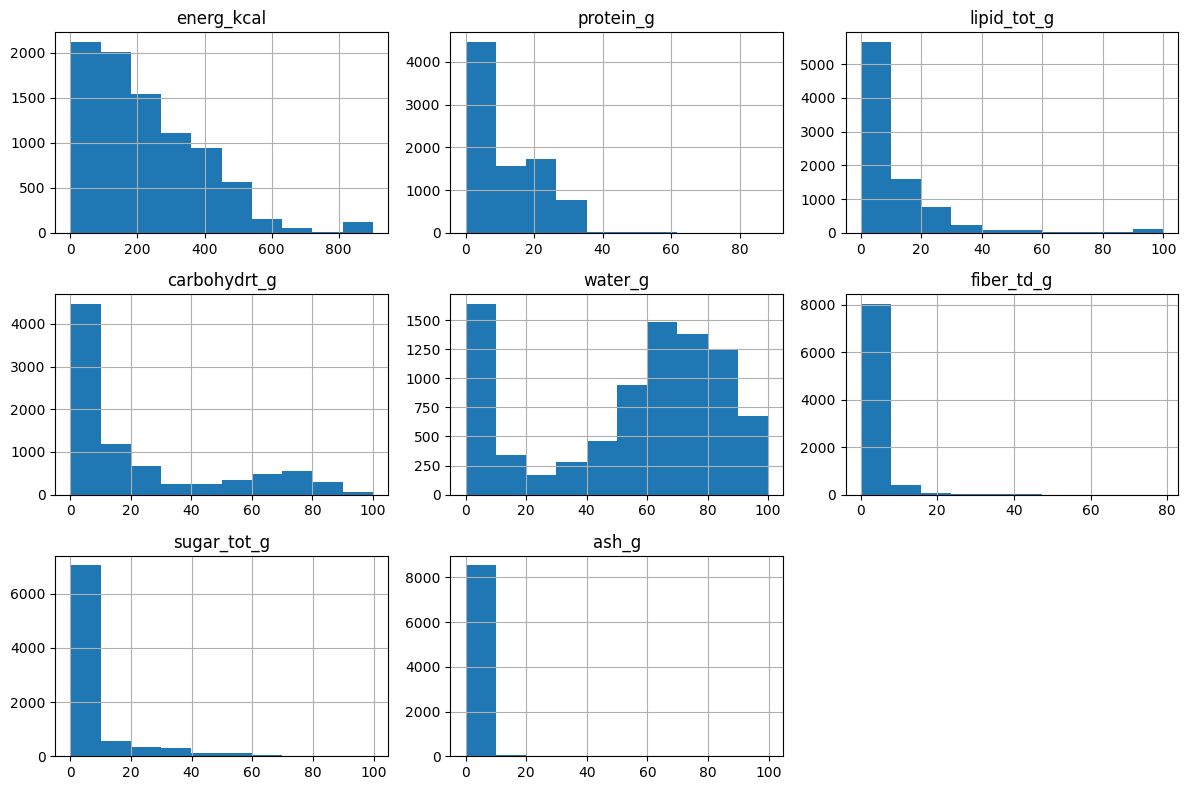

In [29]:
data.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

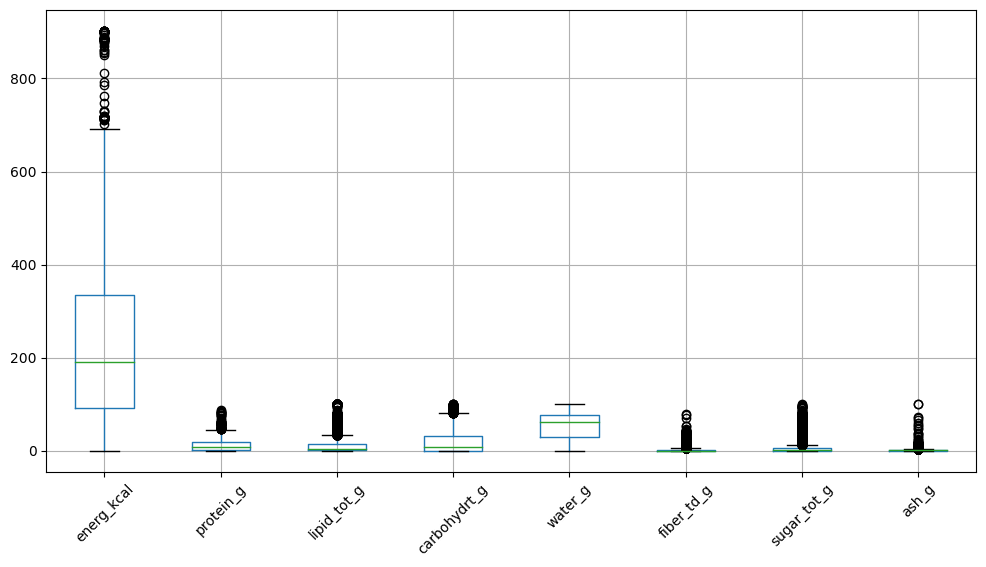

In [30]:
plt.figure(figsize=(12,6))
data.boxplot()
plt.xticks(rotation=45)
plt.show()

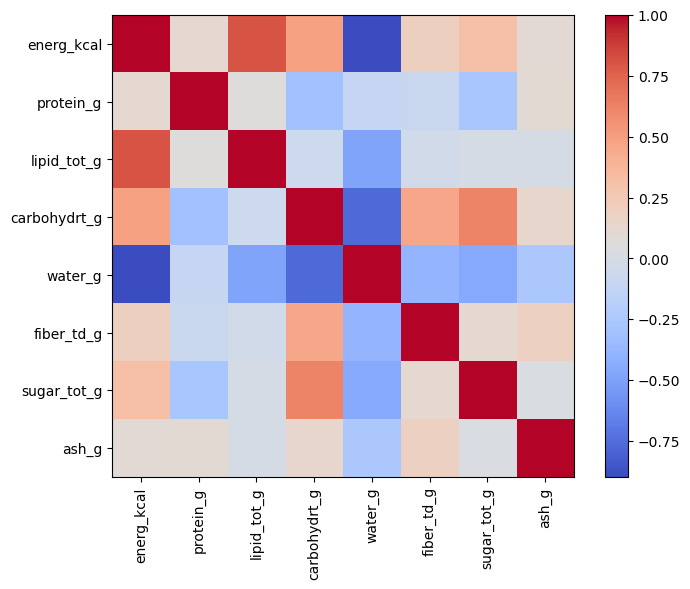

,energ_kcal,protein_g,lipid_tot_g,carbohydrt_g,water_g,fiber_td_g,sugar_tot_g,ash_g
energ_kcal,1.000000,0.110302,0.806795,0.487096,-0.897120,0.195963,0.314354,0.095385
protein_g,0.110302,1.000000,0.054715,-0.301974,-0.104686,-0.074552,-0.268479,0.100172
lipid_tot_g,0.806795,0.054715,1.000000,-0.054116,-0.485319,-0.030208,-0.002766,-0.002565
carbohydrt_g,0.487096,-0.301974,-0.054116,1.000000,-0.771134,0.458672,0.619115,0.136666
water_g,-0.897120,-0.104686,-0.485319,-0.771134,1.000000,-0.383056,-0.458366,-0.253323
fiber_td_g,0.195963,-0.074552,-0.030208,0.458672,-0.383056,1.000000,0.111891,0.177531
sugar_tot_g,0.314354,-0.268479,-0.002766,0.619115,-0.458366,0.111891,1.000000,0.022142
ash_g,0.095385,0.100172,-0.002565,0.136666,-0.253323,0.177531,0.022142,1.000000


In [32]:
corr = data.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

corr

## Model Preparation

The target variable is `energ_kcal`. The remaining nutritional variables are used as predictors. The dataset is divided into training and testing sets before building the regression models.

In [33]:
X = data.drop("energ_kcal", axis=1)
y = data["energ_kcal"]

X.head()

,protein_g,lipid_tot_g,carbohydrt_g,water_g,fiber_td_g,sugar_tot_g,ash_g
0,0.85,81.11,0.06,15.87,0.0,0.06,2.11
1,0.85,81.11,0.06,15.87,0.0,0.06,2.11
2,0.28,99.48,0.00,0.24,0.0,0.00,0.00
3,21.40,28.74,2.34,42.41,0.0,0.50,5.11
4,23.24,29.68,2.79,41.11,0.0,0.51,3.18


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6894, 7)
(1724, 7)


## Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred_linear = linear_model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = mean_squared_error(y_test, y_pred_linear) ** 0.5
linear_r2 = r2_score(y_test, y_pred_linear)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

MAE: 6.10930497334714
RMSE: 12.525858097765354
R2: 0.9945623926209032


## Polynomial Regression

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = mean_squared_error(y_test, y_pred_poly) ** 0.5
poly_r2 = r2_score(y_test, y_pred_poly)

print("MAE:", poly_mae)
print("RMSE:", poly_rmse)
print("R²:", poly_r2)

MAE: 5.050160415097146
RMSE: 10.358598479423021
R²: 0.9962812680936004


## Ridge Regression

In [40]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = mean_squared_error(y_test, y_pred_ridge) ** 0.5
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

MAE: 6.109307590105948
RMSE: 12.525860844275277
R²: 0.994562390236325


## Ridge Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best score:", grid.best_score_)

Best alpha: {'alpha': 100}
Best score: 0.9924317844629684


In [42]:
best_ridge = grid.best_estimator_

y_pred_best = best_ridge.predict(X_test)

best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = mean_squared_error(y_test, y_pred_best) ** 0.5
best_r2 = r2_score(y_test, y_pred_best)

print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)

MAE: 6.109565882157985
RMSE: 12.526143260768885
R²: 0.9945621450335378


## Model Comparison

In [43]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Best Ridge"],
    "MAE": [linear_mae, poly_mae, ridge_mae, best_mae],
    "RMSE": [linear_rmse, poly_rmse, ridge_rmse, best_rmse],
    "R2": [linear_r2, poly_r2, ridge_r2, best_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear,6.109305,12.525858,0.994562
1,Polynomial,5.050160,10.358598,0.996281
2,Ridge,6.109308,12.525861,0.994562
3,Best Ridge,6.109566,12.526143,0.994562


The Polynomial Regression model achieved the best predictive performance, with the lowest RMSE and highest R² among the evaluated models.

# Conclusion

Three regression models were evaluated to predict food energy content using nutritional variables.

Polynomial Regression achieved the best predictive performance, producing the lowest prediction error and the highest R².

This project demonstrated the complete workflow of a basic data science project, including data cleaning, exploratory data analysis, regression modeling, model evaluation, and hyperparameter tuning.

### Thank you!